In [1]:
#Import Libraries
import pandas as pd
import numpy as np
from plotnine import *
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score
np.random.seed(42)



# Data Loading And CLeaning

In [2]:
#load the data and show the first 5 rows
loans = pd.read_csv("loan_risk_prediction_dataset.csv")
loans.head() 
#This is a fully synthetic dataset from kaggle (https://www.kaggle.com/datasets/sohailkhan05/loan-risk-prediction)

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531,549.0,11,Male,NaN,New York,Unemployed,0
4,60,37034.0,27871,500.0,19,Female,High School,Chicago,Unemployed,0


In [3]:
loans.shape #How many rows and columns are in the dataset

(5000, 10)

In [4]:
loans.isna().sum() #Check for missing values in each column to identify which columns have incomplete data.

Age                  0
Income             196
LoanAmount           0
CreditScore        194
YearsExperience      0
Gender               0
Education          198
City                 0
EmploymentType       0
LoanApproved         0
dtype: int64

In [5]:
loans=loans.dropna() #I will remove rows with missing values. It is not ideal as we are losing data, but it is not too much.
loans.shape #This is the shape of the dataset after removing rows with missing values.

(4430, 10)

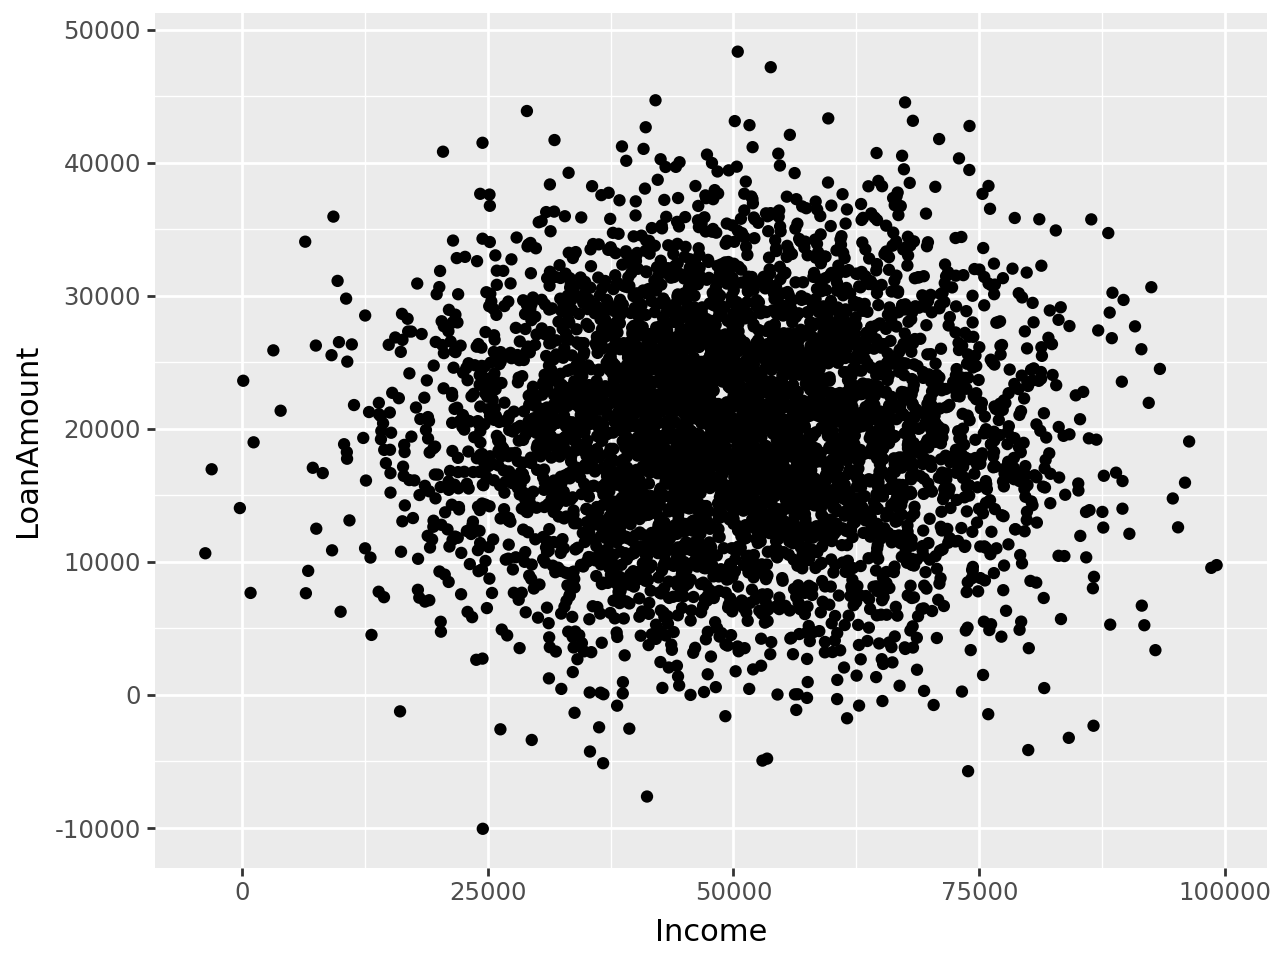

In [6]:
# Now let's visualize Income and Loan Amount
ggplot(loans, aes(x="Income", y="LoanAmount")) + geom_point() 

In [7]:
loans.sort_values("Income", ascending=True).head(5) 

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
2939,65,-3731.0,10651,729.0,22,Male,Masters,San Francisco,Salaried,0
3263,23,-3083.0,16964,331.0,12,Male,PhD,New York,Salaried,0
4523,35,-213.0,14048,582.0,30,Female,Bachelors,Chicago,Self-Employed,0
390,69,129.0,23617,325.0,33,Female,PhD,San Francisco,Self-Employed,0
2354,58,875.0,7670,618.0,1,Male,High School,Houston,Self-Employed,0


I can see three income values are negative. I will get rid of these from the dataset as they may be a mistake.
I also see many Loan amounts are negative and I will remove these too.

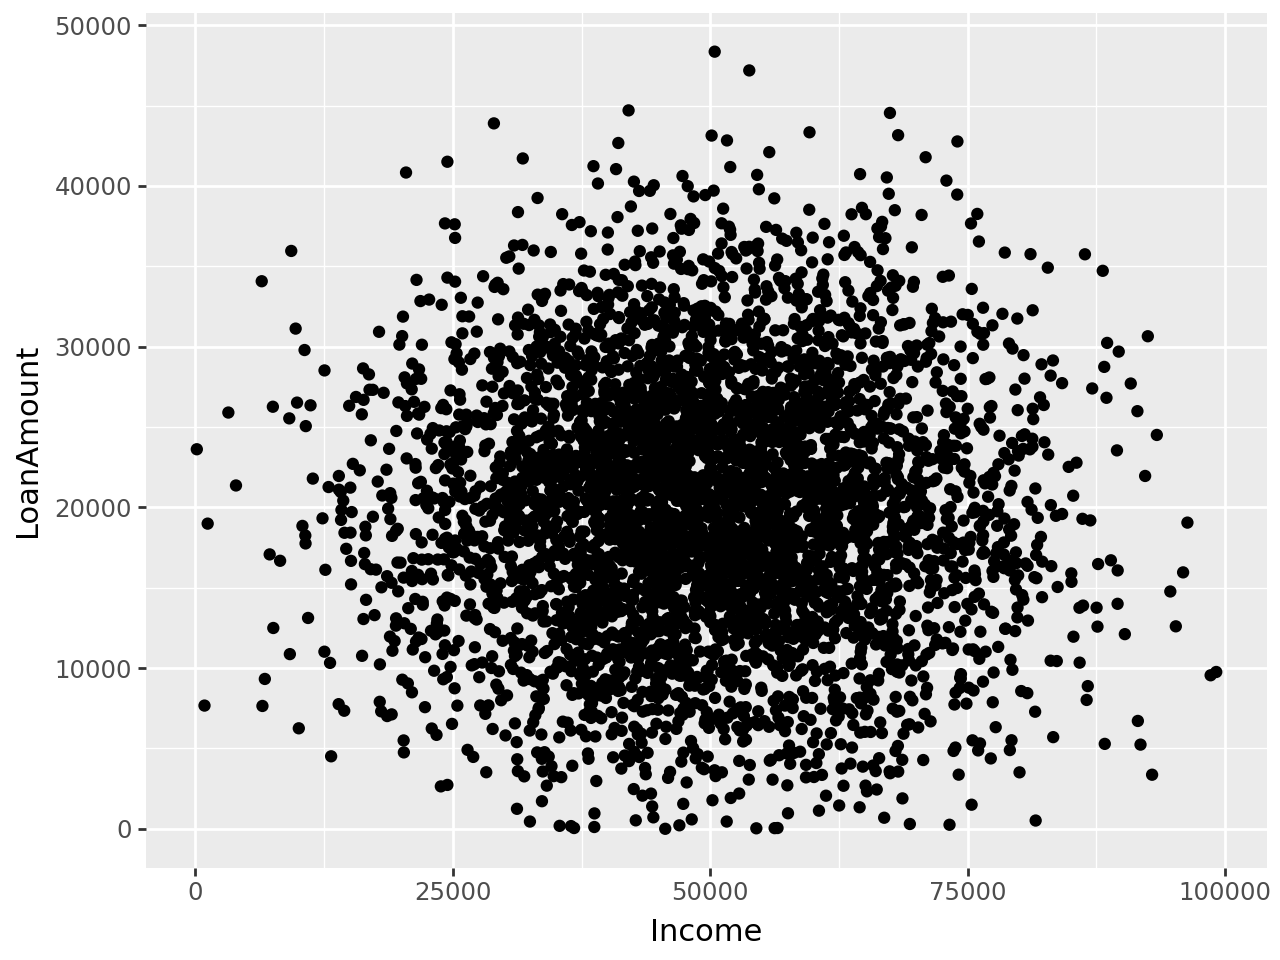

In [8]:
loans = loans[loans['Income']>0]
loans = loans[loans['LoanAmount'] > 0 ]
ggplot(loans, aes(x="Income", y="LoanAmount")) + geom_point()

In [9]:
loans.shape #This is the final shape of the data set after removing rows with missing and suspicious values.

(4401, 10)

# Problem 1

My first problem will be to create two methods to determine whether a loan will be approved. Firstly I will use logistic regression, and secondly random forests. 

I will determine the accuracy of these methods and compare.

## Logistic Regression

For logistic regression, I do not want to many variables. I will drop 'City' and 'YearsExperience' and convert gender to 0 if female and 1 if male. There are 4 different values for Education. As Regression cannot handle string values I will convert them to one hot values.

In [10]:

# 1. Drop the 'City' and 'YearsExperience' columns since they are not useful for prediction
df = loans.drop(columns = ['City', 'YearsExperience'], axis=1)

# 2. Convert categorical text columns into numeric dummy variables
# drop_first=True prevents perfect multicollinearity (the "dummy variable trap")
df_encoded = pd.get_dummies(df, columns=[ 'Gender', 'Education', 'EmploymentType'], drop_first=True, dtype=int)

# 3. Separate your features (X) from your target (y)
X = df_encoded.drop(columns = ['LoanApproved'])
y = df_encoded['LoanApproved']

# 4. Split the data into a training set (80%) and testing set (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Scale the numerical features so large numbers don't dominate small numbers
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Initialize and train the Logistic Regression model
model = LogisticRegression(max_iter=1000, )
model.fit(X_train_scaled, y_train)

# 7. Make predictions on the test set and evaluate
predictions = model.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, predictions):.2f}\n")
print("Classification Report:")
print(classification_report(y_test, predictions))
model.score(X_test_scaled, y_test)


Accuracy: 0.89

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       664
           1       0.81      0.71      0.76       217

    accuracy                           0.89       881
   macro avg       0.86      0.83      0.84       881
weighted avg       0.89      0.89      0.89       881



0.8887627695800226

We can see from above the accuracy of the logistic regression model on the test data was 89%.

It is worth noting that the most simple model of refusing every loan would get an accuracy score of 664/881 = 75%.

## Random Forests

In [11]:
# Now let's try a Random Forest Classifier using the same columns and data splits as before.

# 1. Initialize the Random Forest
# n_estimators=100 means we are building 100 individual decision trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the model
rf_model.fit(X_train, y_train)

# 3. Make predictions
rf_predictions = rf_model.predict(X_test)

# 4. Evaluate the results
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_predictions):.2f}\n")
print(classification_report(y_test, rf_predictions))

Random Forest Accuracy: 0.97

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       664
           1       0.96      0.90      0.93       217

    accuracy                           0.97       881
   macro avg       0.96      0.95      0.95       881
weighted avg       0.97      0.97      0.97       881



In [12]:
# Create copies of the training and test data used for the rf_model (I use in problem 2)
X_train_rf = X_train.copy()
y_train_rf = y_train.copy()
X_test_rf = X_test.copy()
y_test_rf = y_test.copy()
scaler_rf = scaler

We can visualize the performance using an AUC-ROC curve.

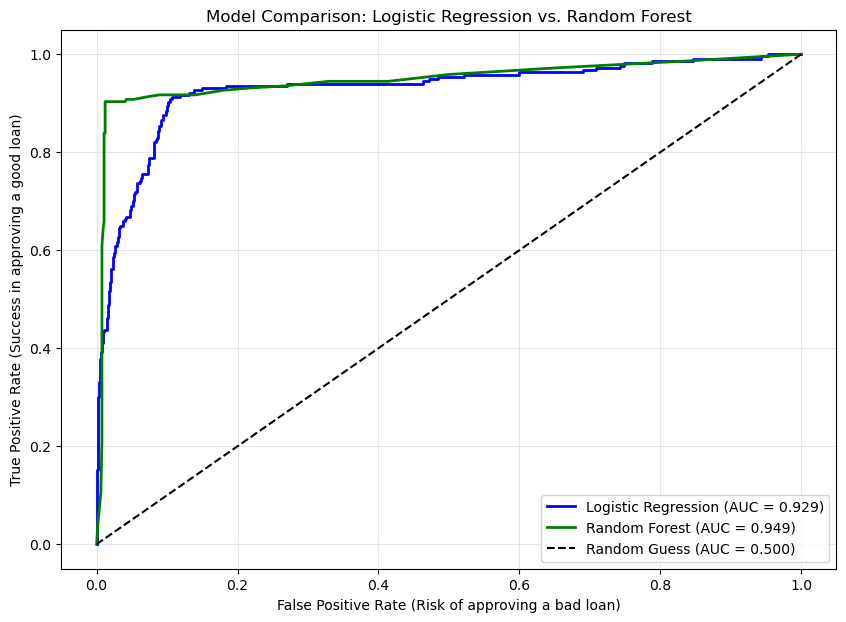

In [13]:
# 1. Clean and Prepare Data (Ensuring no NaNs and proper encoding)
df_clean = loans.drop(columns=['City', 'YearsExperience']).dropna()
df_encoded = pd.get_dummies(df_clean, columns=['Gender', 'Education', 'EmploymentType'], drop_first=True, dtype=int)

X = df_encoded.drop('LoanApproved', axis=1)
y = df_encoded['LoanApproved']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Scale data (Critical for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Train both models
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train) # RF doesn't strictly need scaling, but works with it too

# 4. Get probabilities for the "Approved" (1) class
log_probs = log_model.predict_proba(X_test_scaled)[:, 1]
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# 5. Calculate ROC data
fpr_log, tpr_log, _ = roc_curve(y_test, log_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

auc_log = roc_auc_score(y_test, log_probs)
auc_rf = roc_auc_score(y_test, rf_probs)

# 6. Plotting
plt.close('all')
plt.figure(figsize=(10, 7))

plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {auc_log:.3f})', color='blue', lw=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})', color='green', lw=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.500)')

plt.xlabel('False Positive Rate (Risk of approving a bad loan)')
plt.ylabel('True Positive Rate (Success in approving a good loan)')
plt.title('Model Comparison: Logistic Regression vs. Random Forest')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

We can see that the Random Forest has a larger area under the curve.

Logistic regression assigns a probability for whether the loan is approved or not. Then it is up to us to decide what threshold to assign approval or not. By default the threshold is 0.5. We can see from the sharp elbow that there is a good point to set the threshold to improve the logistic regression model. However, as the Random Forest is clearly better, from now on I will just focus on the random forests model.

We can use the random forest model to see what features are the most important in deciding loan approval.

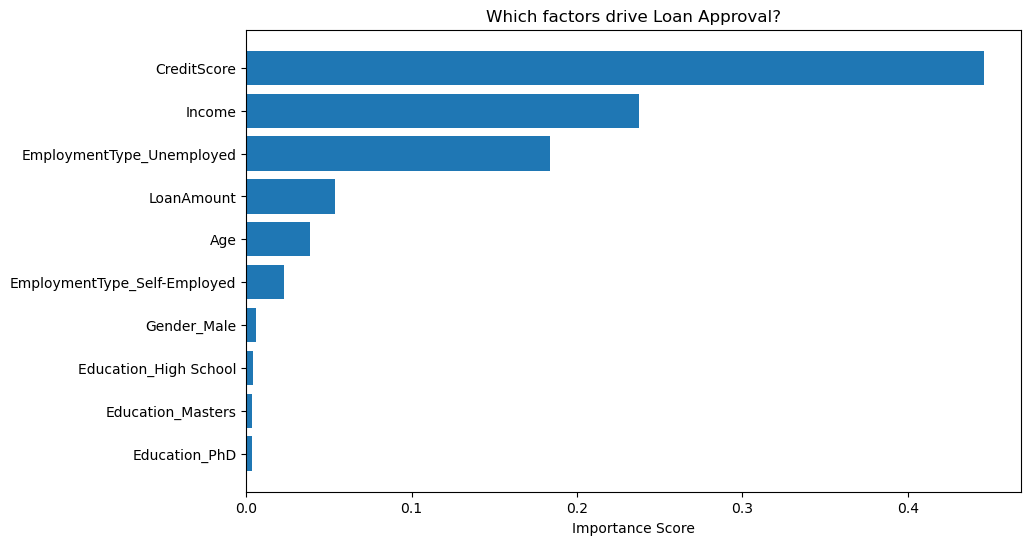

In [14]:
#Graph the importance of the columns
plt.close('all')
# Get importance levels
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Visualize it
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importance Score')
plt.title('Which factors drive Loan Approval?')
plt.gca().invert_yaxis()
plt.show()

Credit Score seems more important than Income!


Education seems not so important. I will actually redo logistic regression again without education. Fewer variables will reduce overfitting and may lead to a better model.

In [15]:
#Logistic regression without education
# 1. Drop the 'City' and 'YearsExperience' columns since they are not useful for prediction
df_no_education = loans.drop(columns = ['City', 'YearsExperience', 'Education'], axis=1)

# 2. Convert categorical text columns into numeric dummy variables
# drop_first=True prevents perfect multicollinearity (the "dummy variable trap")
df_no_education_encoded = pd.get_dummies(df_no_education, columns=[ 'Gender', 'EmploymentType'], drop_first=True, dtype=int)

# 3. Separate your features (X) from your target (y)
X = df_encoded.drop(columns = ['LoanApproved'])
y = df_encoded['LoanApproved']

# 4. Split the data into a training set (80%) and testing set (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Scale the numerical features so large numbers don't dominate small numbers
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Initialize and train the Logistic Regression model
model = LogisticRegression(max_iter=1000, )
model.fit(X_train_scaled, y_train)

# 7. Make predictions on the test set and evaluate
predictions = model.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, predictions):.2f}\n")
print("Classification Report:")
print(classification_report(y_test, predictions))
model.score(X_test_scaled, y_test)


Accuracy: 0.89

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       664
           1       0.81      0.71      0.76       217

    accuracy                           0.89       881
   macro avg       0.86      0.83      0.84       881
weighted avg       0.89      0.89      0.89       881



0.8887627695800226

It is almost unchanged.

## Comparison

One of logistic regression's assumptions is that the feature variables are independent. This is one of the reason's why I removed 'YearsExperience'- it was bound to be strongly correlated to Age. 

However I suspect most (if not all) of the columns will be dependent on each other in some way. Hence logistic regression is not suitable here.


# Problem 2

I now wonder for the people whose loans were not approved, what could they have applied for and been succesful?

My goal is now to make a function that takes as an input the people's data, and returns what amount of money they can apply for and be preducted a succesful loan with the rf_model.


But first I want to check- does this problem make sense? If you apply for less money are you more likely to be approved? I will check this with the first ten people of the rf_test model (their data is already converted to a for the model can use)

In [16]:
people = []
for i in range(10):
    people.append(X_test_rf.iloc[i:i+1])
people

[     Age   Income  LoanAmount  CreditScore  Gender_Male  \
 311   41  57496.0       14720        587.0            1   
 
      Education_High School  Education_Masters  Education_PhD  \
 311                      1                  0              0   
 
      EmploymentType_Self-Employed  EmploymentType_Unemployed  
 311                             0                          1  ,
       Age   Income  LoanAmount  CreditScore  Gender_Male  \
 3887   22  61670.0       27890        316.0            0   
 
       Education_High School  Education_Masters  Education_PhD  \
 3887                      0                  0              0   
 
       EmploymentType_Self-Employed  EmploymentType_Unemployed  
 3887                             0                          0  ,
       Age   Income  LoanAmount  CreditScore  Gender_Male  \
 4561   26  50270.0       24705        684.0            1   
 
       Education_High School  Education_Masters  Education_PhD  \
 4561                      0          

In [17]:
predictions =[]
for person in people:
    predictions.append(int(rf_model.predict(person)[0]))
predictions

[0, 0, 0, 0, 0, 0, 1, 0, 0, 0]

In [18]:
#so only one person had an approved loan, If i change the loan amount to 100 dollars for all of them, do more loans get approved?
for person in people:
    person['LoanAmount'] = 100
people

C:\Users\Dell\AppData\Local\Temp\ipykernel_28616\119304917.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


[     Age   Income  LoanAmount  CreditScore  Gender_Male  \
 311   41  57496.0         100        587.0            1   
 
      Education_High School  Education_Masters  Education_PhD  \
 311                      1                  0              0   
 
      EmploymentType_Self-Employed  EmploymentType_Unemployed  
 311                             0                          1  ,
       Age   Income  LoanAmount  CreditScore  Gender_Male  \
 3887   22  61670.0         100        316.0            0   
 
       Education_High School  Education_Masters  Education_PhD  \
 3887                      0                  0              0   
 
       EmploymentType_Self-Employed  EmploymentType_Unemployed  
 3887                             0                          0  ,
       Age   Income  LoanAmount  CreditScore  Gender_Male  \
 4561   26  50270.0         100        684.0            1   
 
       Education_High School  Education_Masters  Education_PhD  \
 4561                      0          

In [19]:
predictions =[]
for person in people:
    predictions.append(int(rf_model.predict(person)[0]))
list(predictions)

[0, 0, 0, 0, 0, 0, 1, 0, 0, 0]

Changing the loan amount does not make a difference to whether they get approved or not (in this model using this synthetic dataset), hence we will not be able to make such a function. This is also explained by the fact that 'loanAmount' is not that important in the graph of problem 1.

It would be interesting to try this with a real dataset.